# Human-evaluation

# STEP 1 — Setup: imports, project paths, and input checks

In [1]:

import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    """
    Find the repository root by walking upward until both
    'inputs/' and 'outputs/' directories are found.
    """
    cur = start.resolve()
    for _ in range(25):
        if (cur / "inputs").is_dir() and (cur / "outputs").is_dir():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise RuntimeError(
  
    )


ROOT = find_project_root(Path.cwd())

# Inputs (downloaded dataset)
DATASET_DIR = ROOT / "inputs" / "dataset"
INPUT_BRANCH = "primary"  
PRIMARY_DIR = DATASET_DIR / INPUT_BRANCH / "primary-human-evaluation"
# Outputs 
OUT_DIR = ROOT / "outputs" / "human-evaluation"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
# Input files 
EVAL_FILE = PRIMARY_DIR / "data-1760978361180.csv"
BG_FILE   = PRIMARY_DIR / "data-1760978508376.csv"
# Create output dirs
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT       : {ROOT}")
print(f"PRIMARY_DIR: {PRIMARY_DIR}")
print(f"OUT_DIR    : {OUT_DIR}")
print(f"EVAL_FILE  : exists={EVAL_FILE.exists()}  path={EVAL_FILE}")
print(f"BG_FILE    : exists={BG_FILE.exists()}    path={BG_FILE}")

if not PRIMARY_DIR.exists():
    raise FileNotFoundError(
        f"Missing input folder: {PRIMARY_DIR}\n"
        "Expected: inputs/dataset/primary/primary-human-evaluation/\n"
        "Tip: Download the dataset, name the folder 'dataset', and place it under inputs/."
    )
if not EVAL_FILE.exists():
    raise FileNotFoundError(f"Missing evaluation file: {EVAL_FILE}")
if not BG_FILE.exists():
    raise FileNotFoundError(f"Missing background file: {BG_FILE}")

print("Step 1 OK")

ROOT       : /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code
PRIMARY_DIR: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/inputs/dataset/primary/primary-human-evaluation
OUT_DIR    : /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation
EVAL_FILE  : exists=True  path=/home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/inputs/dataset/primary/primary-human-evaluation/data-1760978361180.csv
BG_FILE    : exists=True    path=/home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/inputs/dataset/primary/primary-human-evaluation/data-1760978508376.csv
Step 1 OK


# STEP 2 — Load CSVs and filter background to evaluators

In [2]:

eval_df = pd.read_csv(EVAL_FILE)
bg_df   = pd.read_csv(BG_FILE)

print(f"Evaluation file: rows={len(eval_df)} cols={len(eval_df.columns)}")
print(f"Background file: rows={len(bg_df)} cols={len(bg_df.columns)}")

required_eval_cols = {
    "participantId",
    "dmpName",
    "evaluations",
    "overallAuthorshipGuess",
    "overallSatisfaction",
}
missing_eval_cols = sorted(required_eval_cols - set(eval_df.columns))
if missing_eval_cols:
    raise KeyError(f"Evaluation CSV missing required columns: {missing_eval_cols}")

if "participantId" not in bg_df.columns:
    raise KeyError(
        "Background CSV missing required column: 'participantId'. "
        f"Available columns: {list(bg_df.columns)}"
    )

eval_df["participantId"] = eval_df["participantId"].astype("string")
bg_df["participantId"]   = bg_df["participantId"].astype("string")

eval_participants = eval_df["participantId"].dropna().unique()

bg_filt = (
    bg_df.dropna(subset=["participantId"])
         .loc[lambda d: d["participantId"].isin(eval_participants)]
         .copy()
)

n_eval_participants = int(pd.Series(eval_participants).nunique())
n_bg_participants   = int(bg_filt["participantId"].nunique())

print(f"Unique participants in eval_df: {n_eval_participants}")
print(f"Unique participants in bg_filt: {n_bg_participants}")

bg_filt_path = TAB_DIR / "background_filtered_to_evaluators.csv"
bg_filt.to_csv(bg_filt_path, index=False, encoding="utf-8")
print(f"Saved: {bg_filt_path.as_posix()}")

print("Step 2 OK")

Evaluation file: rows=63 cols=6
Background file: rows=26 cols=15
Unique participants in eval_df: 21
Unique participants in bg_filt: 21
Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_filtered_to_evaluators.csv
Step 2 OK


# STEP 3 — Cleaning process

In [3]:
eval_clean = eval_df.copy()

eval_clean["participantId"] = eval_clean["participantId"].astype("string")
eval_clean["dmpName"] = eval_clean["dmpName"].astype("string").str.strip()


PREFIX_TO_MODEL = {"X": "Llama", "Y": "GPT", "Z": "Human"}
PATTERN = re.compile(r"^([XYZ])_(\d+)$", flags=re.IGNORECASE)

def normalize_dmp_name(s):
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return s
    t = str(s).strip()
    m = PATTERN.fullmatch(t)
    return f"{PREFIX_TO_MODEL[m.group(1).upper()]}_{m.group(2)}" if m else t

eval_clean["dmpName"] = eval_clean["dmpName"].apply(normalize_dmp_name)

def infer_model(dmp_name: str) -> str:
    s = (dmp_name or "").lower()
    if s.startswith("human") or "human" in s:
        return "Human"
    if s.startswith("llama") or "llama" in s:
        return "Llama"
    if s.startswith("gpt") or "gpt" in s:
        return "GPT"
    return "Unknown"

eval_clean["model"] = eval_clean["dmpName"].apply(infer_model)

print("Step 3 OK")
print("Model counts:", eval_clean["model"].value_counts(dropna=False).to_dict())

Step 3 OK
Model counts: {'GPT': 21, 'Llama': 21, 'Human': 21}


# STEP 4 — Expand evaluations into an element-level

In [4]:

def parse_list_of_dicts(raw):
    """
    Parse the 'evaluations' field into a list of dicts.
    Supports:
      - list already
      - JSON string
      - Python literal string (ast.literal_eval)
    Returns [] on failure.
    """
    if isinstance(raw, list):
        return raw
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return []
    if not isinstance(raw, str) or not raw.strip():
        return []

    s = raw.strip()

    try:
        obj = json.loads(s)
        return obj if isinstance(obj, list) else []
    except Exception:
        pass

    s2 = re.sub(r"\.\.\.\s*$", "", s).strip()
    try:
        obj = json.loads(s2)
        return obj if isinstance(obj, list) else []
    except Exception:
        pass

    try:
        obj = ast.literal_eval(s2)
        return obj if isinstance(obj, list) else []
    except Exception:
        return []

rows = []
bad_parse = []

for _, r in eval_clean.iterrows():
    raw_eval = r.get("evaluations", None)
    items = parse_list_of_dicts(raw_eval)

    if isinstance(raw_eval, str) and raw_eval.strip() and not items:
        bad_parse.append({
            "id": r.get("id"),
            "participantId": r.get("participantId"),
            "dmpName": r.get("dmpName"),
        })

    for it in items:
        if not isinstance(it, dict):
            continue

        selected_errors = it.get("selectedErrors", [])
        if selected_errors is None:
            selected_errors = []
        if not isinstance(selected_errors, list):
            selected_errors = [selected_errors]

        rows.append({
            "id": r.get("id"),
            "participantId": r.get("participantId"),
            "dmpName": r.get("dmpName"),
            "model": r.get("model"),
            "overallAuthorshipGuess": r.get("overallAuthorshipGuess"),
            "overallSatisfaction": r.get("overallSatisfaction"),
            "elementTitle": it.get("elementTitle"),
            "selectedErrors": selected_errors,
            "satisfactionScore": it.get("satisfactionScore"),
            "additionalComments": it.get("additionalComments", ""),
        })

expanded = pd.DataFrame(rows)

print(f"Expanded rows: {len(expanded)}")
print(f"Rows with non-empty evaluations but parse failure: {len(bad_parse)}")

expanded_path = TAB_DIR / "expanded_evaluations.csv"
expanded.to_csv(expanded_path, index=False, encoding="utf-8")
print(f"Saved: {expanded_path.as_posix()}")

bad_parse_df = pd.DataFrame(bad_parse)
bad_parse_path = TAB_DIR / "expanded_evaluations_parse_failures.csv"
bad_parse_df.to_csv(bad_parse_path, index=False, encoding="utf-8")
print(f"Saved: {bad_parse_path.as_posix()}")

print("Step 4 OK")

Expanded rows: 378
Rows with non-empty evaluations but parse failure: 0
Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/expanded_evaluations.csv
Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/expanded_evaluations_parse_failures.csv
Step 4 OK


# STEP 4A — Duplicate checks for expanded evaluations

In [5]:

required_cols = {"participantId", "dmpName", "elementTitle"}
missing = sorted(required_cols - set(expanded.columns))
if missing:
    raise KeyError(f"Expanded table missing required columns for duplicate checks: {missing}")

expanded["participantId"] = expanded["participantId"].astype("string")
expanded["dmpName"] = expanded["dmpName"].astype("string")
expanded["elementTitle"] = expanded["elementTitle"].astype("string").fillna("MISSING_ELEMENT_TITLE")

key_cols = ["participantId", "dmpName", "elementTitle"]

key_dup_mask = expanded.duplicated(subset=key_cols, keep=False)
n_key_dups = int(key_dup_mask.sum())

print(f"Expanded rows: {len(expanded)}")
print(f"Duplicate element keys {key_cols}: {n_key_dups}")

if n_key_dups > 0:
    key_dups_path = TAB_DIR / "expanded_key_duplicates.csv"
    expanded.loc[key_dup_mask].sort_values(key_cols).to_csv(
        key_dups_path, index=False, encoding="utf-8"
    )
    print(f"Saved key duplicates: {key_dups_path.as_posix()}")

hashable = expanded.copy()

def to_hashable(x):
    if isinstance(x, (list, dict)):
        return json.dumps(x, sort_keys=True, ensure_ascii=False)
    return x

obj_cols = hashable.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    hashable[c] = hashable[c].apply(to_hashable)

exact_dup_mask = hashable.duplicated(keep=False)
n_exact_dups = int(exact_dup_mask.sum())

print(f"Exact duplicate rows (all columns, list/dict-safe): {n_exact_dups}")

if n_exact_dups > 0:
    exact_dups_path = TAB_DIR / "expanded_exact_duplicates.csv"
    expanded.loc[exact_dup_mask].sort_values(key_cols).to_csv(
        exact_dups_path, index=False, encoding="utf-8"
    )
    print(f"Saved exact duplicates: {exact_dups_path.as_posix()}")

if n_key_dups == 0 and n_exact_dups == 0:
    print("Step 4A OK: No duplicates detected in expanded evaluations.")
else:
    print("Step 4B completed: Duplicates detected. See saved CSV files for inspection.")

Expanded rows: 378
Duplicate element keys ['participantId', 'dmpName', 'elementTitle']: 0
Exact duplicate rows (all columns, list/dict-safe): 0
Step 4A OK: No duplicates detected in expanded evaluations.


# STEP 5 — Satisfaction tables (overall + element-level ordinal)

In [6]:

expanded2 = expanded.copy()

expanded2["participantId"] = expanded2["participantId"].astype("string")
expanded2["dmpName"] = expanded2["dmpName"].astype("string")

overall_unit = expanded2.drop_duplicates(subset=["participantId", "dmpName"]).copy()
overall_unit["overallSatisfaction"] = pd.to_numeric(overall_unit["overallSatisfaction"], errors="coerce")
overall_unit = overall_unit[overall_unit["overallSatisfaction"].between(1, 5)].copy()

model_order = ["Human", "Llama", "GPT"]
overall_unit = overall_unit[overall_unit["model"].isin(model_order)].copy()

print(f"Overall satisfaction valid rows: {len(overall_unit)}")

counts_tbl = (
    overall_unit.groupby(["model", "overallSatisfaction"])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
                .reindex(model_order)
)

row_totals = counts_tbl.sum(axis=1).replace(0, np.nan)
perc_tbl = (counts_tbl.div(row_totals, axis=0) * 100).fillna(0).round(1)

summary_tbl = (
    overall_unit.groupby("model")["overallSatisfaction"]
                .agg(N="count", mean="mean", std="std", median="median", min="min", max="max")
                .reindex(model_order)
                .round({"mean": 3, "std": 3, "median": 3})
)

sat_map = {
    "very dissatisfied": 1,
    "dissatisfied": 2,
    "neither dissatisfied or satisfied": 3,
    "satisfied": 4,
    "very satisfied": 5,
}

expanded2["satisfactionOrdinal"] = (
    expanded2["satisfactionScore"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(sat_map)
)

elem_ok = expanded2["satisfactionOrdinal"].between(1, 5) & expanded2["model"].isin(model_order)
element_unit = expanded2.loc[elem_ok, ["model", "elementTitle", "satisfactionOrdinal"]].copy()

print(f"Element satisfaction mapped rows: {len(element_unit)}")

elem_counts_tbl = (
    element_unit.groupby(["model", "satisfactionOrdinal"])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
                .reindex(model_order)
)

counts_path = TAB_DIR / "overall_satisfaction_counts_by_model.csv"
perc_path   = TAB_DIR / "overall_satisfaction_percent_by_model.csv"
summ_path   = TAB_DIR / "overall_satisfaction_summary_by_model.csv"
elem_path   = TAB_DIR / "element_satisfaction_counts_by_model.csv"

counts_tbl.to_csv(counts_path, encoding="utf-8")
perc_tbl.to_csv(perc_path, encoding="utf-8")
summary_tbl.to_csv(summ_path, encoding="utf-8")
elem_counts_tbl.to_csv(elem_path, encoding="utf-8")

print("Saved:")
print(f" - {counts_path.as_posix()}")
print(f" - {perc_path.as_posix()}")
print(f" - {summ_path.as_posix()}")
print(f" - {elem_path.as_posix()}")

print("Step 5 OK")

Overall satisfaction valid rows: 63
Element satisfaction mapped rows: 377
Saved:
 - /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/overall_satisfaction_counts_by_model.csv
 - /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/overall_satisfaction_percent_by_model.csv
 - /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/overall_satisfaction_summary_by_model.csv
 - /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/element_satisfaction_counts_by_model.csv
Step 5 OK


# STEP 5A — Figure: Overall satisfaction distribution by model

/tmp/ipykernel_3214435/948958475.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")


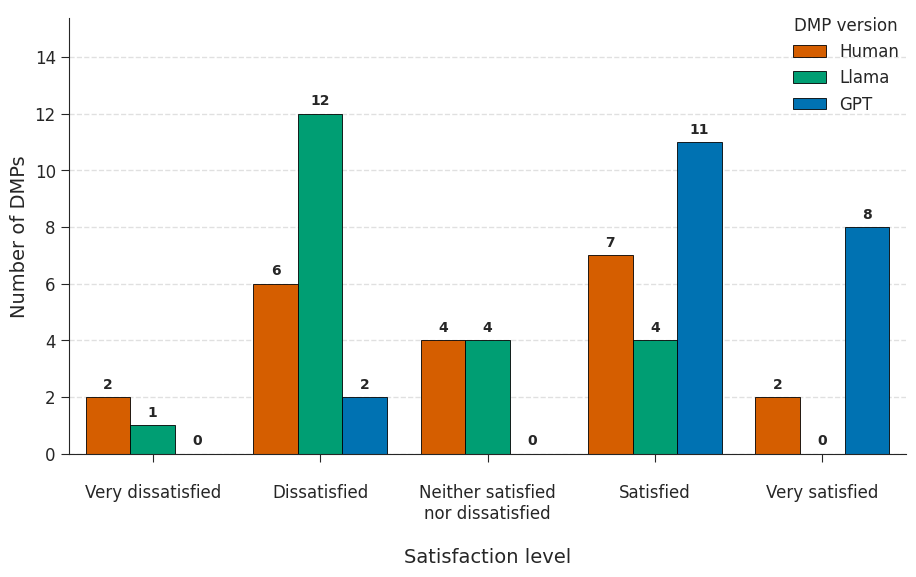

Saved figure: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures/overall_satisfaction_by_group.png
Step 5A OK


In [7]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(
    style="ticks",
    font="DejaVu Sans",
    rc={
        "font.size": 10,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,  
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
    },
)

wong = {
    "Green": "#009E73",
    "Blue": "#0072B2",
    "Vermillion": "#D55E00",
}

model_order = ["Human", "Llama", "GPT"]
group_to_color = {
    "Human": wong["Vermillion"],
    "Llama": wong["Green"],
    "GPT": wong["Blue"],
}
palette_list = [group_to_color[m] for m in model_order]

df_plot = expanded.copy()

required_cols = {"participantId", "dmpName", "model", "overallSatisfaction"}
missing = sorted(required_cols - set(df_plot.columns))
if missing:
    raise KeyError(f"Missing required columns for Step 5A plot: {missing}")

df_plot["participantId"] = df_plot["participantId"].astype("string")
df_plot["dmpName"] = df_plot["dmpName"].astype("string")
df_plot = df_plot.drop_duplicates(subset=["participantId", "dmpName"]).copy()

df_plot = df_plot[df_plot["model"].isin(model_order)].copy()
df_plot["DMP version"] = df_plot["model"]

df_plot["overallSatisfaction"] = pd.to_numeric(df_plot["overallSatisfaction"], errors="coerce")
df_plot = df_plot[df_plot["overallSatisfaction"].between(1, 5)].copy()
df_plot["overallSatisfaction"] = df_plot["overallSatisfaction"].astype(int)

score_to_label = {
    1: "Very dissatisfied",
    2: "Dissatisfied",
    3: "Neither satisfied\nnor dissatisfied",
    4: "Satisfied",
    5: "Very satisfied",
}
df_plot["Satisfaction level"] = df_plot["overallSatisfaction"].map(score_to_label)

x_order = [
    "Very dissatisfied",
    "Dissatisfied",
    "Neither satisfied\nnor dissatisfied",
    "Satisfied",
    "Very satisfied",
]

counts = (
    df_plot.groupby(["Satisfaction level", "DMP version"])
           .size()
           .reset_index(name="Count")
)

all_idx = pd.MultiIndex.from_product(
    [x_order, model_order],
    names=["Satisfaction level", "DMP version"]
)
counts = (
    counts.set_index(["Satisfaction level", "DMP version"])
          .reindex(all_idx, fill_value=0)
          .reset_index()
)


fig, ax = plt.subplots(figsize=(10.8, 6.4))

sns.barplot(
    data=counts,
    x="Satisfaction level",
    y="Count",
    hue="DMP version",
    order=x_order,
    hue_order=model_order,
    palette=palette_list,
    saturation=1,
    dodge=True,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
)

for p in ax.patches:
    p.set_alpha(1.0)

ax.set_xlabel("Satisfaction level", labelpad=18) 
ax.set_ylabel("Number of DMPs")
ax.tick_params(axis="x", pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
ymax = (counts["Count"].max() * 1.28) if len(counts) else 1
ax.set_ylim(0, max(1, ymax))


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )

ax.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine(ax=ax)


ax.legend(
    title="DMP version",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.02),
    borderaxespad=0.0,
)


fig.subplots_adjust(bottom=0.22, top=0.90)
fig_path = FIG_DIR / "overall_satisfaction_by_group.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved figure:", fig_path.as_posix())
print("Step 5A OK")

# STEP 6 — Authorship guess correctness (Human vs LLM)


Authorship guess correctness counts:
is_correct   Guess correct  Guess incorrect
source_norm                                
Human                   14                7
Llama                   15                6
GPT                      3               18
Saved table: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/authorship_guess_correctness_counts.csv


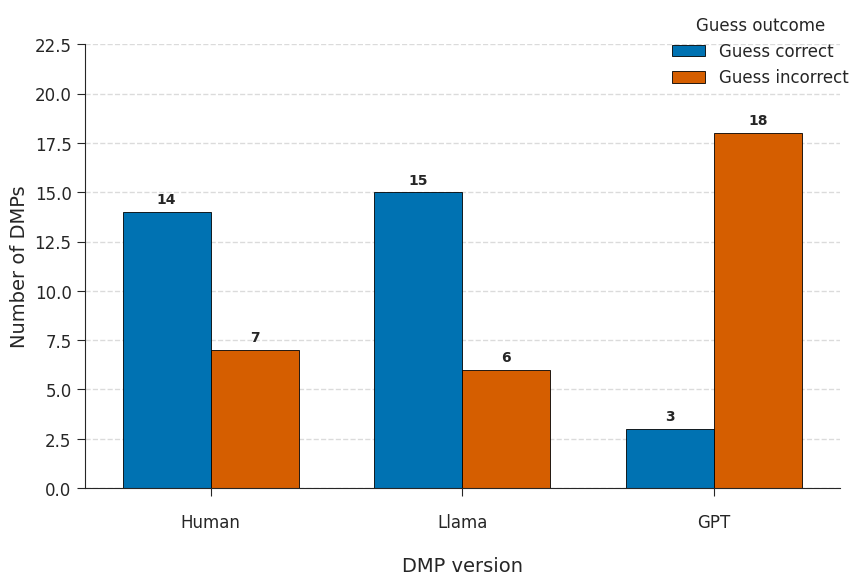

Saved figure: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures/authorship_guess_correctness_by_model.png
Step 6 OK


In [8]:
df = eval_clean.copy()

required_cols = {"dmpName", "overallAuthorshipGuess"}
missing = sorted(required_cols - set(df.columns))
if missing:
    raise KeyError(f"Missing required columns for Step 6: {missing}")

def extract_author_from_dmp(name):
    if pd.isna(name):
        return None
    s = str(name).strip().lower()
    if s.startswith("llama"):
        return "Llama"
    if s.startswith("gpt"):
        return "GPT"
    if s.startswith("human"):
        return "Human"
    return None

def expected_group_from_source(src):
    if src in ("Llama", "GPT"):
        return "llm"
    if src == "Human":
        return "human"
    return None

def normalize_guess(g):
    if not isinstance(g, str):
        return None
    s = g.strip().lower()
    if "human" in s:
        return "human"
    if ("llm" in s) or ("gpt" in s) or ("chatgpt" in s) or ("llama" in s) or ("ai" in s) or ("model" in s):
        return "llm"
    return None

df["source"] = df["dmpName"].apply(extract_author_from_dmp)
df["expected_group"] = df["source"].apply(expected_group_from_source)
df["guess_group"] = df["overallAuthorshipGuess"].apply(normalize_guess)

df["is_correct"] = np.where(
    df["expected_group"].notna()
    & df["guess_group"].notna()
    & (df["expected_group"] == df["guess_group"]),
    1, 0
)

df2 = df[df["expected_group"].notna() & df["guess_group"].notna()].copy()
df2["Guess outcome"] = df2["is_correct"].map({1: "Guess correct", 0: "Guess incorrect"})
df2["source_norm"] = df2["source"]

acc_counts = (
    df2.groupby("source_norm")["is_correct"]
       .value_counts()
       .unstack(fill_value=0)
       .rename(columns={1: "Guess correct", 0: "Guess incorrect"})
)

for col in ["Guess correct", "Guess incorrect"]:
    if col not in acc_counts.columns:
        acc_counts[col] = 0

acc_counts = acc_counts[["Guess correct", "Guess incorrect"]]
acc_counts = acc_counts.reindex([m for m in model_order if m in acc_counts.index])

print("\nAuthorship guess correctness counts:")
print(acc_counts)

table_path = TAB_DIR / "authorship_guess_correctness_counts.csv"
acc_counts.to_csv(table_path, encoding="utf-8")
print("Saved table:", table_path.as_posix())

plot_df = (
    acc_counts.reset_index()
              .melt(id_vars="source_norm", var_name="Guess outcome", value_name="Count")
              .rename(columns={"source_norm": "DMP version"})
)


# Seaborn style 

sns.set(
    style="ticks",
    font="DejaVu Sans",
    rc={
        "font.size": 10,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,  
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
    },
)

hue_order = ["Guess correct", "Guess incorrect"]
palette_list = [wong["Blue"], wong["Vermillion"]]


# Plot

fig, ax = plt.subplots(figsize=(8.6, 6.6))  

sns.barplot(
    data=plot_df,
    x="DMP version",
    y="Count",
    hue="Guess outcome",
    order=acc_counts.index.tolist(),
    hue_order=hue_order,
    palette=palette_list,
    saturation=1,
    dodge=True,
    edgecolor="black",
    width=0.70,
    linewidth=0.6,
    ax=ax,
)

for p in ax.patches:
    p.set_alpha(1.0)


ax.set_ylabel("Number of DMPs")
ax.tick_params(axis="x", pad=12)
ax.set_xlabel("DMP version", labelpad=18)
max_val = plot_df["Count"].max() if len(plot_df) else 1
ax.set_ylim(0, max(1, max_val) * 1.25)


for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=10, fontweight="bold", clip_on=False)

ax.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine(ax=ax)


handles, labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()

fig.legend(
    handles,
    labels,
    title="Guess outcome",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.88),
    borderaxespad=0.0,
)


fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.86])
fig_path = FIG_DIR / "authorship_guess_correctness_by_model.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved figure:", fig_path.as_posix())
print("Step 6 OK")

# STEP 7 — Element-level error + satisfaction analysis

In [9]:

def assert_no_duplicates(expanded_df: pd.DataFrame, tab_dir: Path) -> None:
    required = {"participantId", "dmpName", "elementTitle"}
    missing = sorted(required - set(expanded_df.columns))
    if missing:
        raise KeyError(f"Expanded table missing columns required for duplicate gate: {missing}")

    df = expanded_df.copy()
    df["participantId"] = df["participantId"].astype("string")
    df["dmpName"] = df["dmpName"].astype("string")
    df["elementTitle"] = df["elementTitle"].astype("string").fillna("MISSING_ELEMENT_TITLE")

    key_cols = ["participantId", "dmpName", "elementTitle"]
    key_dup_mask = df.duplicated(subset=key_cols, keep=False)
    n_key_dups = int(key_dup_mask.sum())

    hashable = df.copy()

    def to_hashable(x):
        if isinstance(x, (list, dict)):
            return json.dumps(x, sort_keys=True, ensure_ascii=False)
        return x

    obj_cols = hashable.select_dtypes(include=["object", "string"]).columns
    for c in obj_cols:
        hashable[c] = hashable[c].apply(to_hashable)

    exact_dup_mask = hashable.duplicated(keep=False)
    n_exact_dups = int(exact_dup_mask.sum())

    print("Duplicate gate check:")
    print(f" - Key duplicates {key_cols}: {n_key_dups}")
    print(f" - Exact duplicates (all columns): {n_exact_dups}")

    if n_key_dups > 0:
        p = tab_dir / "step7_block_key_duplicates.csv"
        df.loc[key_dup_mask].sort_values(key_cols).to_csv(p, index=False, encoding="utf-8")
        raise RuntimeError(f"STEP 7 blocked: key-level duplicates found. See: {p.as_posix()}")

    if n_exact_dups > 0:
        p = tab_dir / "step7_block_exact_duplicates.csv"
        df.loc[exact_dup_mask].sort_values(key_cols).to_csv(p, index=False, encoding="utf-8")
        raise RuntimeError(f"STEP 7 blocked: exact duplicates found. See: {p.as_posix()}")

    print("Duplicate gate passed: proceeding with Step 7.")


STEP7_TAB_DIR = TAB_DIR
STEP7_FIG_DIR = FIG_DIR

assert_no_duplicates(expanded, STEP7_TAB_DIR)



# Helper functions
def make_element_short(s):
    if pd.isna(s):
        return None
    m = re.search(r"(?i)\b(elem(?:ent|n|nt)?)\s*(\d+)", str(s))
    return f"Element {m.group(2)}" if m else None

def element_order_key(x):
    if not isinstance(x, str):
        return 1_000_000
    m = re.search(r"Element\s+(\d+)", x)
    return int(m.group(1)) if m else 1_000_000

def parse_errors(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or str(x).strip() == "":
        return []
    s = str(x)
    try:
        v = json.loads(s)
        return v if isinstance(v, list) else [str(v)]
    except Exception:
        try:
            v = ast.literal_eval(s)
            return v if isinstance(v, list) else [str(v)]
        except Exception:
            return [s]

def clean_error_list(lst):
    keep = []
    for e in lst:
        s = str(e).strip()
        if re.fullmatch(r"(?i)none(\s*--.*)?", s):
            continue
        if re.fullmatch(r"(?i)no\s*errors?\s*seen", s):
            continue
        if s == "":
            continue
        keep.append(s)
    return keep

def simplify_error_label(lbl):
    return str(lbl).split("--", 1)[0].strip()

def extract_model(dmp):
    if pd.isna(dmp):
        return "Unknown"
    s = str(dmp).split("_")[0].strip().lower()
    if s == "gpt":
        return "GPT"
    if s == "llama":
        return "Llama"
    if s == "human":
        return "Human"
    return "Unknown"



# Preprocessing

work = expanded.copy()
if "satisfactionOrdinal" not in work.columns:
    sat_map = {
        "very dissatisfied": 1,
        "dissatisfied": 2,
        "neither dissatisfied or satisfied": 3,
        "satisfied": 4,
        "very satisfied": 5,
    }
    work["satisfactionOrdinal"] = (
        work["satisfactionScore"]
        .astype("string")
        .str.strip()
        .str.lower()
        .map(sat_map)
    )
    mapped_n = int(work["satisfactionOrdinal"].notna().sum())
    print(f"Created satisfactionOrdinal from satisfactionScore (mapped rows: {mapped_n} / {len(work)})")

work["elementShort"] = work["elementTitle"].apply(make_element_short)
work["parsedErrors"] = work["selectedErrors"].apply(parse_errors).apply(clean_error_list)
work["model"] = work["dmpName"].apply(extract_model)

model_types = ["GPT", "Llama", "Human"]



# Per-model outputs
for model in model_types:
    print(f"\nMODEL: {model}")
    df_model = work[work["model"] == model].copy()

    err_exp = (
        df_model
        .explode("parsedErrors")
        .assign(errorSimple=lambda d: d["parsedErrors"].fillna("").astype(str).map(simplify_error_label))
    )
    err_exp = err_exp[
        err_exp["errorSimple"].str.strip().ne("") &
        err_exp["errorSimple"].str.lower().ne("none")
    ]

    error_counts = (
        err_exp
        .groupby(["elementShort", "errorSimple"], dropna=False)
        .size()
        .reset_index(name="count")
    )
    error_counts["__ord"] = error_counts["elementShort"].map(element_order_key)
    error_counts = error_counts.sort_values(["__ord", "count"], ascending=[True, False]).drop(columns="__ord")
    error_counts.to_csv(STEP7_TAB_DIR / f"error_counts_{model}.csv", index=False, encoding="utf-8")

    error_matrix = (
        error_counts
        .pivot(index="errorSimple", columns="elementShort", values="count")
        .fillna(0)
        .astype(int)
    )
    if len(error_matrix.columns) > 0:
        error_matrix = error_matrix[sorted(error_matrix.columns, key=element_order_key)]
    error_matrix = error_matrix.sort_index()
    error_matrix.to_csv(STEP7_TAB_DIR / f"error_matrix_{model}.csv", encoding="utf-8")

    sat_stats = (
        df_model
        .dropna(subset=["elementShort", "satisfactionOrdinal"])
        .groupby("elementShort", as_index=False)["satisfactionOrdinal"]
        .agg(mean="mean", std="std", n="count", median="median")
    )
    sat_stats["__ord"] = sat_stats["elementShort"].map(element_order_key)
    sat_stats = sat_stats.sort_values("__ord").drop(columns="__ord").reset_index(drop=True)
    sat_stats.to_csv(STEP7_TAB_DIR / f"satisfaction_stats_{model}.csv", index=False, encoding="utf-8")

    top_errors = (
        error_counts
        .groupby("elementShort", as_index=False)
        .apply(lambda g: ", ".join(g.sort_values("count", ascending=False).head(3)["errorSimple"].tolist()))
        .reset_index(drop=True)
        .rename(columns={0: "topErrors"})
    )
    summary = sat_stats.merge(top_errors, on="elementShort", how="left")
    summary.to_csv(STEP7_TAB_DIR / f"element_summary_{model}.csv", index=False, encoding="utf-8")

   


element_labels = {
    "Element 1": "Types and Amount of Scientific Data; Data to be Preserved and Shared; Metadata and Documentation",
    "Element 2": "Tools, Software, and Code",
    "Element 3": "Standards",
    "Element 4": "Repository, Findability, and Availability Timeline",
    "Element 5": "Access, Distribution, Reuse, Controlled Access, Privacy, and Confidentiality",
    "Element 6": "Oversight of DMP",
}

all_stats = []
for model in model_types:
    df_stats = pd.read_csv(STEP7_TAB_DIR / f"satisfaction_stats_{model}.csv")
    df_stats["model"] = model
    all_stats.append(df_stats)

df_all = pd.concat(all_stats, ignore_index=True)
df_all["mean_std"] = df_all.apply(lambda r: f"{r['mean']:.1f}±{r['std']:.2f}", axis=1)

table = df_all.pivot(index="elementShort", columns="model", values="mean_std").reset_index()
table.insert(1, "elementField", table["elementShort"].map(element_labels))
table = table.sort_values("elementShort", key=lambda col: col.map(element_order_key))

table.columns.name = None
table = table.rename(columns={
    "elementShort": "elementNumber",
    "Llama": "Llama 3.3",
    "GPT": "GPT 4.1",
    "Human": "Human",
})

final_path = STEP7_TAB_DIR / "satisfaction_comparison_table.csv"
table.to_csv(final_path, index=False, encoding="utf-8")

print("\nSaved Step 7 outputs to:")
print(" - Tables :", STEP7_TAB_DIR.as_posix())
print(" - Figures:", STEP7_FIG_DIR.as_posix())
print(" - Comparison table:", final_path.as_posix())
print("Step 7 OK")

Duplicate gate check:
 - Key duplicates ['participantId', 'dmpName', 'elementTitle']: 0
 - Exact duplicates (all columns): 0
Duplicate gate passed: proceeding with Step 7.
Created satisfactionOrdinal from satisfactionScore (mapped rows: 377 / 378)

MODEL: GPT

MODEL: Llama



MODEL: Human


/tmp/ipykernel_3214435/1083746489.py:191: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ", ".join(g.sort_values("count", ascending=False).head(3)["errorSimple"].tolist()))
/tmp/ipykernel_3214435/1083746489.py:191: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ", ".join(g.sort_values("count", ascending=False).head(3)["errorSimple"].tolist()))
/tmp/ipykernel_3214435/1083746489.py:191: 


Saved Step 7 outputs to:
 - Tables : /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables
 - Figures: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures
 - Comparison table: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/satisfaction_comparison_table.csv
Step 7 OK


# STEP 8 — Background (survey) analysis

In [10]:

import re
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# 8.1 Load + filter to evaluators
background_df = pd.read_csv(BG_FILE)
eval_df2 = pd.read_csv(EVAL_FILE)

if "participantId" not in background_df.columns:
    raise KeyError("Background file missing 'participantId'")
if "participantId" not in eval_df2.columns:
    raise KeyError("Evaluation file missing 'participantId'")

background_df = background_df.dropna(subset=["participantId"]).copy()
background_df["participantId"] = background_df["participantId"].astype("string")

eval_ids = eval_df2["participantId"].dropna().astype("string").unique()

df_bg = background_df[background_df["participantId"].isin(eval_ids)].copy()
N_true = int(df_bg["participantId"].nunique())
print(f"Filtered participants (evaluation cohort): {N_true}")

# Save filtered background
bg_filt_path = TAB_DIR / "background_filtered_to_evaluators_step8.csv"
df_bg.to_csv(bg_filt_path, index=False, encoding="utf-8")
print("Saved:", bg_filt_path.as_posix())

Filtered participants (evaluation cohort): 21
Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_filtered_to_evaluators_step8.csv


# 8.2 Helpers

In [11]:



def wrap_two_lines(s: str, width: int = 42) -> str:
    return "\n".join(textwrap.wrap(str(s), width=width))

def parse_list(value):
    """Handle values like '{"A","B"}' or "['A','B']" or 'A,B'."""
    if pd.isna(value):
        return []
    text = str(value).strip()
    text = text.strip("{}[]")
    text = text.replace('"', "").replace("'", "")
    parts = re.split(r",|;|\|", text)
    return [p.strip() for p in parts if p.strip()]

def ordered_counts_from_series(series, order):
    """Return counts for an ordered categorical series + N responders for that panel."""
    responders = series.dropna().astype(str).str.strip()
    responders = responders[(responders != "") & (responders.str.lower() != "nan")]
    N_panel = int(responders.shape[0])

    cat = pd.Categorical(responders, categories=order, ordered=True)
    out = pd.Series(cat).value_counts(dropna=False).reindex(order).fillna(0).astype(int).reset_index()
    out.columns = ["Category", "Count"]
    return out, N_panel

# 8.3 Roles (multi-select) normalization

In [12]:


ROLE_CATEGORIES = {
    "Researcher": "Researcher (e.g., student, faculty, post-doctoral)",
    "Admin": "Research administrator / Program officer",
    "DataMgr": "Data manager / Data steward",
    "Librarian": "Librarian / Data librarian / Research support staff",
    "Other": "Other",
}

ROLE_KEYWORDS = {
    "researcher": ROLE_CATEGORIES["Researcher"],
    "student": ROLE_CATEGORIES["Researcher"],
    "faculty": ROLE_CATEGORIES["Researcher"],
    "post": ROLE_CATEGORIES["Researcher"],

    "administrator": ROLE_CATEGORIES["Admin"],
    "program officer": ROLE_CATEGORIES["Admin"],
    "program manager": ROLE_CATEGORIES["Admin"],

    "data manager": ROLE_CATEGORIES["DataMgr"],
    "data steward": ROLE_CATEGORIES["DataMgr"],

    "librarian": ROLE_CATEGORIES["Librarian"],
    "research support": ROLE_CATEGORIES["Librarian"],
}

def map_role_to_category(role_str):
    if not isinstance(role_str, str):
        return ROLE_CATEGORIES["Other"]
    t = role_str.lower()
    for k, cat in ROLE_KEYWORDS.items():
        if k in t:
            return cat
    return ROLE_CATEGORIES["Other"]

if "roles" not in df_bg.columns:
    raise KeyError("Background table missing required column 'roles' for Step 8 figure.")

role_rows = []
for pid, raw in zip(df_bg["participantId"], df_bg["roles"]):
    for r in parse_list(raw):
        role_rows.append({"participantId": pid, "Category": map_role_to_category(r)})

roles_long = pd.DataFrame(role_rows).drop_duplicates()
N_A = int(roles_long["participantId"].nunique()) if not roles_long.empty else 0

# Role summary table (multi-select)
roles_counts = roles_long["Category"].value_counts().reset_index()
roles_counts.columns = ["Role Category", "Selections"]

roles_counts["Participants"] = (
    roles_long.groupby("Category")["participantId"].nunique()
    .reindex(roles_counts["Role Category"])
    .values
)
roles_counts["Percent_of_participants"] = (roles_counts["Participants"] / N_true * 100).round(1)

roles_counts_path = TAB_DIR / "background_roles_summary.csv"
roles_counts.to_csv(roles_counts_path, index=False, encoding="utf-8")
print("Saved:", roles_counts_path.as_posix())

participant_roles = (
    roles_long[["participantId", "Category"]]
    .drop_duplicates()
    .groupby("participantId")["Category"]
    .apply(lambda s: ", ".join(sorted(s.unique())))
    .reset_index(name="Role Categories")
    .sort_values("participantId")
)
participant_roles_path = TAB_DIR / "background_roles_per_participant.csv"
participant_roles.to_csv(participant_roles_path, index=False, encoding="utf-8")
print("Saved:", participant_roles_path.as_posix())


Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_roles_summary.csv
Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_roles_per_participant.csv


# 8.4 DMP count (ordered)

In [13]:

if "dmpCount" not in df_bg.columns:
    raise KeyError("Background table missing required column 'dmpCount' for Step 8 figure.")

df_b = df_bg.copy()
df_b["dmpCount"] = (
    df_b["dmpCount"]
    .astype(str)
    .str.replace("â€“", "–", regex=False)  # fix corrupted en-dash
    .str.strip()
)

df_b["dmpCount_clean"] = df_b["dmpCount"].replace({
    "2-3": "2–3",
    "4-5": "4–5",
    "More than five": "More than 5",
    "More than five DMPs": "More than 5",
})

dmp_order = ["1", "2–3", "4–5", "More than 5"]
b_counts, N_B = ordered_counts_from_series(df_b["dmpCount_clean"], dmp_order)

b_counts_path = TAB_DIR / "background_dmpCount_summary.csv"
b_counts.assign(Percent=(b_counts["Count"] / max(1, N_B) * 100).round(1)).to_csv(
    b_counts_path, index=False, encoding="utf-8"
)
print("Saved:", b_counts_path.as_posix())


Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_dmpCount_summary.csv


# 8.5 DMP review frequency (ordered)

In [14]:

if "dmpReviewFrequency" not in df_bg.columns:
    raise KeyError("Background table missing required column 'dmpReviewFrequency' for Step 8 figure.")

freq_order = ["Weekly or more often", "About once a month", "Every few months", "Once or twice a year"]
c_counts, N_C = ordered_counts_from_series(df_bg["dmpReviewFrequency"], freq_order)

c_counts_path = TAB_DIR / "background_dmpReviewFrequency_summary.csv"
c_counts.assign(Percent=(c_counts["Count"] / max(1, N_C) * 100).round(1)).to_csv(
    c_counts_path, index=False, encoding="utf-8"
)
print("Saved:", c_counts_path.as_posix())


Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_dmpReviewFrequency_summary.csv


# 8.6 Familiarity with NIH DMP requirements (ordered)

In [15]:

if "dmsFamiliarity" not in df_bg.columns:
    raise KeyError("Background table missing required column 'dmsFamiliarity' for Step 8 figure.")

fam_order = ["Slightly familiar", "Somewhat familiar", "Moderately familiar", "Extremely familiar"]
d_counts, N_D = ordered_counts_from_series(df_bg["dmsFamiliarity"], fam_order)

d_counts_path = TAB_DIR / "background_dmsFamiliarity_summary.csv"
d_counts.assign(Percent=(d_counts["Count"] / max(1, N_D) * 100).round(1)).to_csv(
    d_counts_path, index=False, encoding="utf-8"
)
print("Saved:", d_counts_path.as_posix())

Saved: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/background_dmsFamiliarity_summary.csv


# 8.7 Plot 

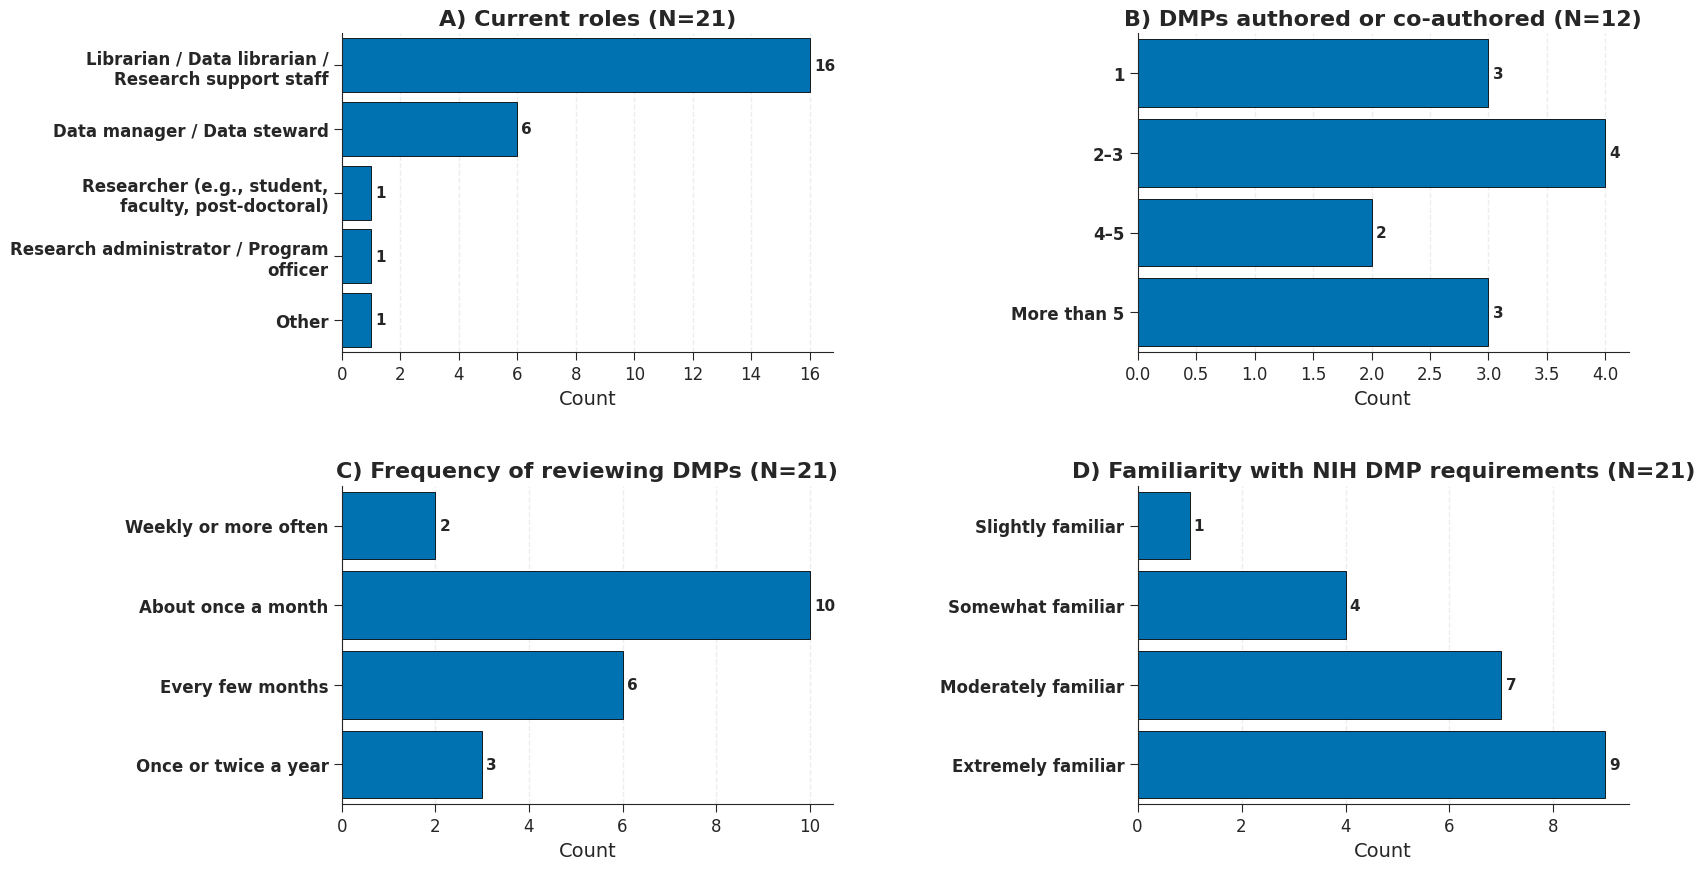

Step 8 OK


In [16]:


def wrap_panelA_label(s: str, width: int = 34) -> str:
    """
    Wrap long role labels for Panel A without breaking words.
    """
    if s is None:
        return ""
    s = str(s).strip()
    if not s or s.lower() == "nan":
        return ""
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))
    
sns.set(
    style="ticks",
    font="DejaVu Sans",
    rc={
        "font.size": 10,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 16,  
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
    },
)

ONE_COLOR = "#0072B2"

# Panel A counts + wrapped labels (use your latest wrapper)
roles_counts_plot = roles_long["Category"].value_counts().reset_index()
roles_counts_plot.columns = ["Category", "Count"]
roles_counts_plot["Category_wrapped"] = roles_counts_plot["Category"].apply(wrap_panelA_label)
roles_sorted = roles_counts_plot.sort_values("Count", ascending=False)


def barh_panel(ax, data, y_col, title, y_order=None, bold_ylabels=False):
    sns.barplot(
        data=data,
        x="Count",
        y=y_col,
        order=y_order,
        color=ONE_COLOR,
        saturation=1,
        edgecolor="black",
        linewidth=0.6,
        width=0.85,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

    if bold_ylabels:
        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")

    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f", padding=3, fontsize=11, fontweight="bold")

    ax.grid(axis="x", linestyle="--", alpha=0.35)  
    sns.despine(ax=ax)


fig, axes = plt.subplots(2, 2, figsize=(16.5, 9.4))  
axes = axes.ravel()


barh_panel(
    axes[0],
    roles_sorted,
    "Category_wrapped",
    f"A) Current roles (N={N_A})",
    y_order=roles_sorted["Category_wrapped"].tolist(),
    bold_ylabels=True,
)

barh_panel(
    axes[1],
    b_counts,
    "Category",
    f"B) DMPs authored or co-authored (N={N_B})",
    y_order=dmp_order,
    bold_ylabels=True,
)

barh_panel(
    axes[2],
    c_counts,
    "Category",
    f"C) Frequency of reviewing DMPs (N={N_C})",
    y_order=freq_order,
    bold_ylabels=True,
)

barh_panel(
    axes[3],
    d_counts,
    "Category",
    f"D) Familiarity with NIH DMP requirements (N={N_D})",
    y_order=fam_order,
    bold_ylabels=True,
)


fig.subplots_adjust(
    left=0.20,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.62,
    hspace=0.42,
)

fig_path = FIG_DIR / "participants_background_dmp_expertise_horizontal_2x2.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", pad_inches=0.02, facecolor="white")
plt.show()
plt.close(fig)

print("Step 8 OK")


# 8.8 Plot

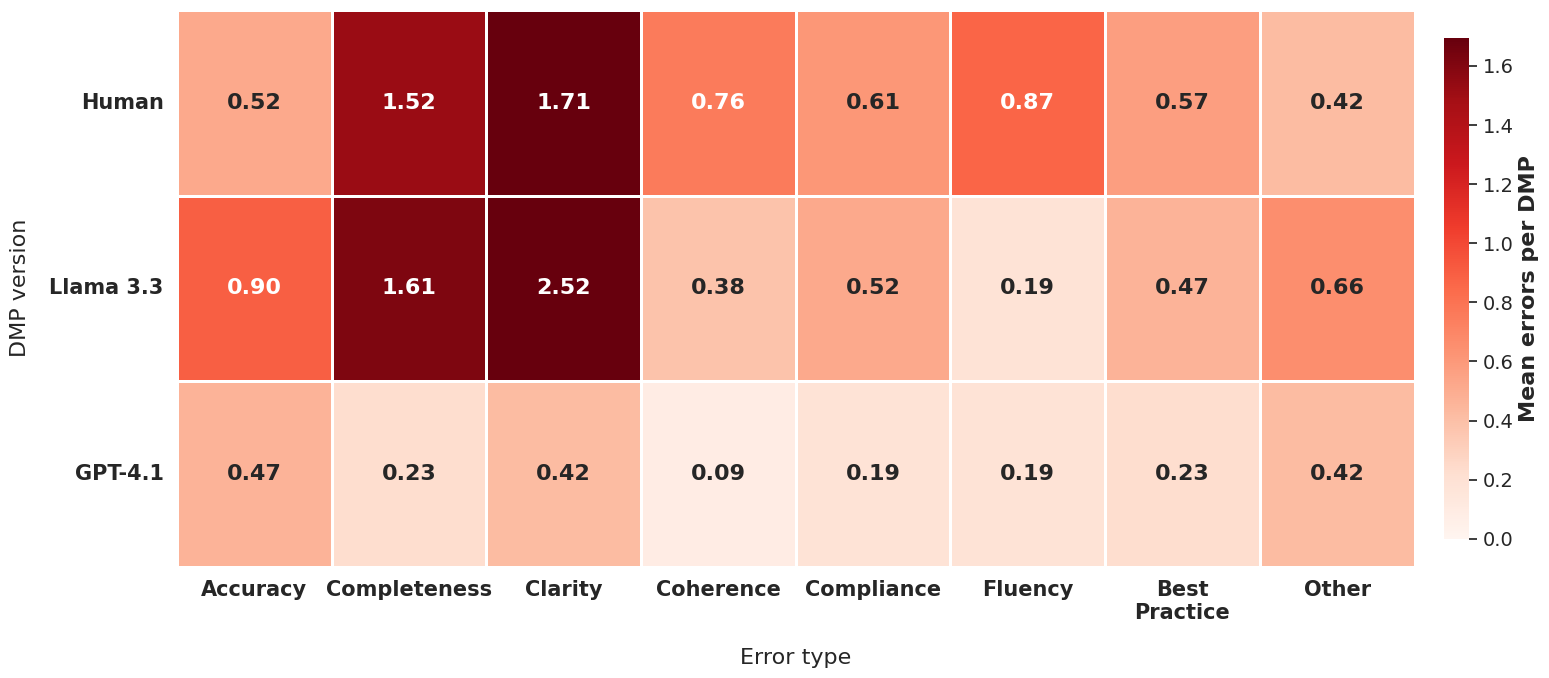

Saved heatmap to: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures/error_heatmap_by_model_pub.png
Color scale used: vmin=0.0, vmax=1.695 (95th percentile)


In [17]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data (from your table)

data = [
    ["Human",     0.52, 1.52, 1.71, 0.76, 0.61, 0.87, 0.57, 0.42],
    ["Llama 3.3", 0.90, 1.61, 2.52, 0.38, 0.52, 0.19, 0.47, 0.66],
    ["GPT-4.1",   0.47, 0.23, 0.42, 0.09, 0.19, 0.19, 0.23, 0.42],
]
cols = [
    "DMP version", "Accuracy", "Completeness", "Clarity", "Coherence",
    "Compliance", "Fluency", "Best Practice", "Other"
]
df_hm = pd.DataFrame(data, columns=cols).set_index("DMP version")

# Stable row/column order (publication)
row_order = ["Human", "Llama 3.3", "GPT-4.1"]
col_order = ["Accuracy", "Completeness", "Clarity", "Coherence",
             "Compliance", "Fluency", "Best Practice", "Other"]
df_hm = df_hm.reindex(index=row_order, columns=col_order)


# Styling 

sns.set(
    style="white",
    font="DejaVu Sans",
    rc={
        "font.size": 14,          
        "axes.titlesize": 20,     
        "axes.titleweight": "bold",
        "axes.labelsize": 16,     
        "xtick.labelsize": 15,    
        "ytick.labelsize": 15,    
    },
)

x_labels = ["Accuracy", "Completeness", "Clarity", "Coherence",
            "Compliance", "Fluency", "Best\nPractice", "Other"]


# vmin / vmax 
vals = df_hm.to_numpy().ravel()
vmin = 0.0
vmax = float(np.percentile(vals, 95))  


# Heatmap

fig, ax = plt.subplots(figsize=(17, 7))
hm = sns.heatmap(
    df_hm,
    ax=ax,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".2f",
    linewidths=1.0,
    linecolor="#FFFFFF",
    cbar=True,
    cbar_kws={"label": "Mean errors per DMP", "shrink": 0.90, "pad": 0.02},
    annot_kws={"fontsize": 16, "fontweight": "bold"}, 
)

ax.set_xlabel("Error type", fontsize=16, labelpad=18)
ax.set_ylabel("DMP version", fontsize=16, labelpad=14)
ax.set_xticklabels(x_labels, rotation=0, ha="center", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight="bold")

# Colorbar label/ticks 
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14) 
cbar.set_label("Mean errors per DMP", fontsize=16, fontweight="bold")  
fig.tight_layout()
fig_path = FIG_DIR / "error_heatmap_by_model_pub.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved heatmap to:", fig_path)
print(f"Color scale used: vmin={vmin}, vmax={vmax:.3f} (95th percentile)")


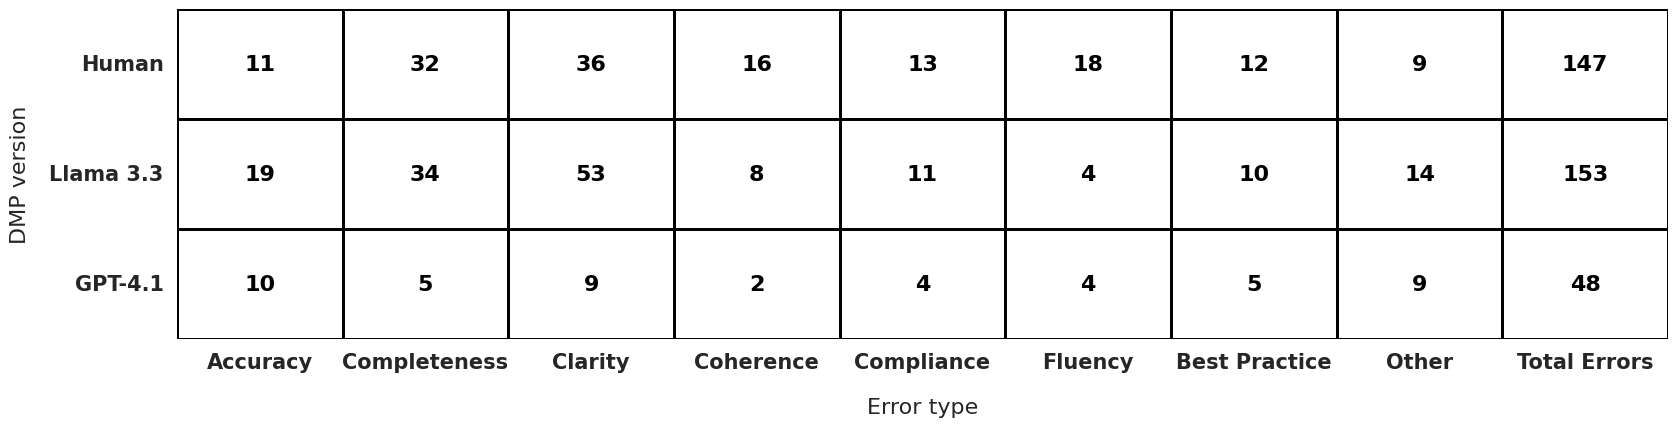

Saved table to: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures/error_table_by_model.jpg


In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap

# Data
data = [
    ["Human",     11, 32, 36, 16, 13, 18, 12, 9, 147],
    ["Llama 3.3", 19, 34, 53, 8, 11, 4, 10, 14, 153],
    ["GPT-4.1",   10, 5, 9, 2, 4, 4, 5, 9, 48],
]

cols = [
    "DMP version", "Accuracy", "Completeness", "Clarity", "Coherence",
    "Compliance", "Fluency", "Best Practice", "Other", "Total Errors"
]

df_hm = pd.DataFrame(data, columns=cols).set_index("DMP version")

# Stable row/column order
row_order = ["Human", "Llama 3.3", "GPT-4.1"]
col_order = ["Accuracy", "Completeness", "Clarity", "Coherence",
             "Compliance", "Fluency", "Best Practice", "Other", "Total Errors"]
df_hm = df_hm.reindex(index=row_order, columns=col_order)


# Styling
sns.set(
    style="white",
    font="DejaVu Sans",
    rc={
        "font.size": 14,
        "axes.titlesize": 20,
        "axes.titleweight": "bold",
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
    },
)

x_labels = ["Accuracy", "Completeness", "Clarity", "Coherence",
            "Compliance", "Fluency", "Best Practice", "Other", "Total Errors"]

# Make a white "table" instead of a red heatmap
white_cmap = ListedColormap(["white"])

fig, ax = plt.subplots(figsize=(17, 4.5))
hm = sns.heatmap(
    df_hm,
    ax=ax,
    cmap=white_cmap,
    cbar=False,
    annot=True,
    fmt="d",
    linewidths=1.0,
    linecolor="black",
    annot_kws={"fontsize": 16, "fontweight": "bold", "color": "black"},
)

ax.set_xlabel("Error type", fontsize=16, labelpad=18)
ax.set_ylabel("DMP version", fontsize=16, labelpad=14)
ax.set_xticklabels(x_labels, rotation=0, ha="center", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight="bold")

fig.tight_layout()

fig_path = FIG_DIR / "error_table_by_model.jpg"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved table to:", fig_path)

# 9 Statistics Test--> In Progress

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# 1. Load file
file_path = Path(r"outputs/human-evaluation/tables/expanded_evaluations.csv")
df = pd.read_csv(file_path)

# 2. Keep needed columns
df = df[["participantId", "model", "elementTitle", "satisfactionScore"]].copy()

# 3. Convert satisfaction labels to numeric 1-5
score_map = {
    "very dissatisfied": 1,
    "dissatisfied": 2,
    "neither dissatisfied or satisfied": 3,
    "satisfied": 4,
    "very satisfied": 5,
}

df["satisfactionScore_clean"] = (
    df["satisfactionScore"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["satisfactionScore_clean"] = df["satisfactionScore_clean"].replace({"nan": np.nan})
df["satisfactionScore_num"] = df["satisfactionScore_clean"].map(score_map)

missing_scores = (
    df.loc[
        df["satisfactionScore_clean"].notna() & df["satisfactionScore_num"].isna(),
        "satisfactionScore_clean"
    ]
    .drop_duplicates()
    .tolist()
)

if missing_scores:
    raise ValueError(f"Unmapped satisfaction labels found: {missing_scores}")

# 4. Standardize model names
df["model"] = df["model"].astype(str).str.strip()

model_map = {
    "GPT": "GPT",
    "GPT4.1": "GPT",
    "GPT 4.1": "GPT",
    "gpt": "GPT",
    "Llama": "Llama",
    "Llama 3.3": "Llama",
    "llama": "Llama",
    "Human": "Human",
    "human": "Human"
}

df["model_clean"] = df["model"].replace(model_map)

unknown_models = sorted(df.loc[df["model_clean"].isna(), "model"].dropna().unique().tolist())
if unknown_models:
    raise ValueError(f"Unknown model labels found: {unknown_models}")

# 5. Standardize element titles
df["elementTitle"] = df["elementTitle"].astype(str).str.strip()

def standardize_element(title):
    t = title.strip().rstrip(":").replace("  ", " ")
    t_lower = t.lower()

    if t_lower.startswith("element 1") or t_lower.startswith("1."):
        return "Element 1"
    elif t_lower.startswith("element 2") or t_lower.startswith("2."):
        return "Element 2"
    elif t_lower.startswith("element 3") or t_lower.startswith("3."):
        return "Element 3"
    elif t_lower.startswith("element 4") or t_lower.startswith("4."):
        return "Element 4"
    elif t_lower.startswith("element 5") or t_lower.startswith("5."):
        return "Element 5"
    elif t_lower.startswith("element 6") or t_lower.startswith("6."):
        return "Element 6"
    else:
        return t

df["element_clean"] = df["elementTitle"].apply(standardize_element)

expected_elements = [f"Element {i}" for i in range(1, 7)]
found_elements = sorted(df["element_clean"].dropna().unique().tolist())
print("Found elements:", found_elements)

# 6. Basic checks
print("\nBasic checks")
print("Rows:", len(df))
print("Unique participants:", df["participantId"].nunique())
print("Models:", sorted(df["model_clean"].unique().tolist()))
print("Elements:", sorted(df["element_clean"].unique().tolist()))

# 7. Descriptive statistics by element and model
desc = (
    df.groupby(["element_clean", "model_clean"])["satisfactionScore_num"]
      .agg(["count", "mean", "std", "median"])
      .reset_index()
      .sort_values(["element_clean", "model_clean"])
)

print("\nDescriptive statistics by element and model")
print(desc)

# 8. Friedman + pairwise Wilcoxon for each element
element_results = []
pairwise_rows = []

comparisons = [("GPT", "Llama"), ("GPT", "Human"), ("Human", "Llama")]

for elem in expected_elements:
    sub = df[df["element_clean"] == elem].copy()

    wide = sub.pivot_table(
        index="participantId",
        columns="model_clean",
        values="satisfactionScore_num",
        aggfunc="mean"
    )

    needed = ["Human", "Llama", "GPT"]
    missing_cols = [c for c in needed if c not in wide.columns]
    if missing_cols:
        print(f"\nSkipping {elem}: missing model columns {missing_cols}")
        continue

    wide = wide.dropna(subset=needed).copy()
    n = len(wide)

    if n < 2:
        print(f"\nSkipping {elem}: not enough complete paired observations")
        continue

    human = wide["Human"]
    llama = wide["Llama"]
    gpt = wide["GPT"]

    friedman_stat, friedman_p = friedmanchisquare(human, llama, gpt)

    raw_pvals = []
    raw_stats = []
    raw_ns = []

    for a, b in comparisons:
        pair = wide[[a, b]].dropna().copy()

        try:
            w_res = wilcoxon(
                pair[a],
                pair[b],
                zero_method="wilcox",
                alternative="two-sided",
                method="exact"
            )
            w_stat = w_res.statistic
            w_p = w_res.pvalue
        except ValueError:
            w_stat = np.nan
            w_p = np.nan

        raw_stats.append(w_stat)
        raw_pvals.append(w_p)
        raw_ns.append(len(pair))

    valid_mask = [not pd.isna(p) for p in raw_pvals]

    corrected_pvals = [np.nan] * len(raw_pvals)
    reject_flags = [False] * len(raw_pvals)

    if any(valid_mask):
        valid_pvals = [p for p in raw_pvals if not pd.isna(p)]
        reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")

        j = 0
        for i, ok in enumerate(valid_mask):
            if ok:
                corrected_pvals[i] = pvals_corr[j]
                reject_flags[i] = reject[j]
                j += 1

    element_results.append({
        "element": elem,
        "n": n,
        "friedman_stat": friedman_stat,
        "friedman_p": friedman_p,
        "human_mean": human.mean(),
        "human_sd": human.std(ddof=1),
        "llama_mean": llama.mean(),
        "llama_sd": llama.std(ddof=1),
        "gpt_mean": gpt.mean(),
        "gpt_sd": gpt.std(ddof=1)
    })

    for (a, b), w_stat, p_raw, p_corr, sig, n_pair in zip(
        comparisons, raw_stats, raw_pvals, corrected_pvals, reject_flags, raw_ns
    ):
        pairwise_rows.append({
            "element": elem,
            "comparison": f"{a} vs {b}",
            "n": n_pair,
            "wilcoxon_stat": w_stat,
            "p_raw": p_raw,
            "p_holm": p_corr,
            "significant": sig
        })

element_results_df = pd.DataFrame(element_results)
pairwise_results_df = pd.DataFrame(pairwise_rows)

print("\nElement-level Friedman results")
print(element_results_df)

print("\nElement-level pairwise Wilcoxon results")
print(pairwise_results_df)

# 9. Overall analysis
# Average the 6 element scores for each participant within each model
overall = (
    df.groupby(["participantId", "model_clean"])["satisfactionScore_num"]
      .mean()
      .reset_index()
)

overall_wide = overall.pivot_table(
    index="participantId",
    columns="model_clean",
    values="satisfactionScore_num",
    aggfunc="mean"
)

overall_wide = overall_wide.dropna(subset=["Human", "Llama", "GPT"]).copy()

n_overall = len(overall_wide)

overall_friedman_stat, overall_friedman_p = friedmanchisquare(
    overall_wide["Human"],
    overall_wide["Llama"],
    overall_wide["GPT"]
)

overall_pairwise = []
overall_raw_pvals = []
overall_raw_stats = []

for a, b in comparisons:
    pair = overall_wide[[a, b]].dropna().copy()

    try:
        w_res = wilcoxon(
            pair[a],
            pair[b],
            zero_method="wilcox",
            alternative="two-sided",
            method="exact"
        )
        w_stat = w_res.statistic
        w_p = w_res.pvalue
    except ValueError:
        w_stat = np.nan
        w_p = np.nan

    overall_pairwise.append({
        "comparison": f"{a} vs {b}",
        "n": len(pair),
        "wilcoxon_stat": w_stat,
        "p_raw": w_p
    })

    overall_raw_stats.append(w_stat)
    overall_raw_pvals.append(w_p)

valid_mask = [not pd.isna(p) for p in overall_raw_pvals]
overall_corrected = [np.nan] * len(overall_raw_pvals)
overall_reject = [False] * len(overall_raw_pvals)

if any(valid_mask):
    valid_pvals = [p for p in overall_raw_pvals if not pd.isna(p)]
    reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")

    j = 0
    for i, ok in enumerate(valid_mask):
        if ok:
            overall_corrected[i] = pvals_corr[j]
            overall_reject[i] = reject[j]
            j += 1

for i in range(len(overall_pairwise)):
    overall_pairwise[i]["p_holm"] = overall_corrected[i]
    overall_pairwise[i]["significant"] = overall_reject[i]

overall_pairwise_df = pd.DataFrame(overall_pairwise)

print("\nOverall Friedman result")
print({
    "n": n_overall,
    "friedman_stat": overall_friedman_stat,
    "friedman_p": overall_friedman_p,
    "human_mean": overall_wide["Human"].mean(),
    "human_sd": overall_wide["Human"].std(ddof=1),
    "llama_mean": overall_wide["Llama"].mean(),
    "llama_sd": overall_wide["Llama"].std(ddof=1),
    "gpt_mean": overall_wide["GPT"].mean(),
    "gpt_sd": overall_wide["GPT"].std(ddof=1),
})

print("\nOverall pairwise Wilcoxon results")
print(overall_pairwise_df)

# 10. Formatting helpers
def format_p(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"

def format_mean_sd(mean_val, sd_val):
    return f"{mean_val:.1f} ± {sd_val:.2f}"


# 11. Optional: save outputs
element_results_df.to_csv("outputs/human-evaluation/tables/human_eval_friedman_results.csv", index=False)
pairwise_results_df.to_csv("outputs/human-evaluation/tables/human_eval_pairwise_wilcoxon_results.csv", index=False)
desc.to_csv("outputs/human-evaluation/tables/human_eval_descriptive_stats.csv", index=False)
overall_pairwise_df.to_csv("outputs/human-evaluation/tables/human_eval_overall_pairwise_results.csv", index=False)

print("\nSaved files:")
print("- outputs/human-evaluation/tables/human_eval_friedman_results.csv")
print("- outputs/human-evaluation/tables/human_eval_pairwise_wilcoxon_results.csv")
print("- outputs/human-evaluation/tables/human_eval_descriptive_stats.csv")
print("- outputs/human-evaluation/tables/human_eval_overall_pairwise_results.csv")

Found elements: ['Element 1', 'Element 2', 'Element 3', 'Element 4', 'Element 5', 'Element 6']

Basic checks
Rows: 378
Unique participants: 21
Models: ['GPT', 'Human', 'Llama']
Elements: ['Element 1', 'Element 2', 'Element 3', 'Element 4', 'Element 5', 'Element 6']

Descriptive statistics by element and model
   element_clean model_clean  count      mean       std  median
0      Element 1         GPT     21  4.095238  1.044259     4.0
1      Element 1       Human     21  2.952381  1.283596     2.0
2      Element 1       Llama     21  3.095238  0.995227     3.0
3      Element 2         GPT     21  4.380952  0.740013     5.0
4      Element 2       Human     21  2.952381  1.499206     4.0
5      Element 2       Llama     21  3.142857  1.062342     3.0
6      Element 3         GPT     21  4.333333  0.912871     4.0
7      Element 3       Human     21  3.190476  1.167007     3.0
8      Element 3       Llama     21  3.380952  1.244033     4.0
9      Element 4         GPT     21  3.857143  1.


Element-level Friedman results
     element   n  friedman_stat  friedman_p  human_mean  human_sd  llama_mean  \
0  Element 1  21       9.514286    0.008590    2.952381  1.283596    3.095238   
1  Element 2  21      17.848485    0.000133    2.952381  1.499206    3.142857   
2  Element 3  21      13.323077    0.001279    3.190476  1.167007    3.380952   
3  Element 4  21      13.303030    0.001292    2.904762  1.135991    2.523810   
4  Element 5  21      12.243243    0.002195    3.142857  1.388730    2.571429   
5  Element 6  20       9.241379    0.009846    3.400000  1.187656    3.000000   

   llama_sd  gpt_mean    gpt_sd  
0  0.995227  4.095238  1.044259  
1  1.062342  4.380952  0.740013  
2  1.244033  4.333333  0.912871  
3  1.123345  3.857143  1.108409  
4  1.207122  4.047619  1.023533  
5  1.256562  4.150000  0.812728  

Element-level pairwise Wilcoxon results
      element      comparison   n  wilcoxon_stat     p_raw    p_holm  \
0   Element 1    GPT vs Llama  21           35.0 

# Step 10 — Ordinal Mixed Model Analysis (CLMM + LMM)

Step 9's Friedman + Wilcoxon tests provide distribution-free validation. Below we
augment with two mixed models that use the full element-level data (n=377) without
collapsing to participant means first:

1. **Cumulative Link Mixed Model (CLMM)** — the principled model for ordinal
   repeated-measures data. Models P(satisfaction ≤ k) via proportional odds,
   with a random intercept for participant.
2. **Linear Mixed Model (LMM)** — pragmatic alternative treating 1–5 scores as
   approximately continuous. Gives Cohen's d effect sizes and ICC.

Both should agree with Step 9 on direction and significance.

## 10.1 — Prepare element-level data for mixed models

In [20]:
import subprocess
import json as json_mod
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm, chi2

# Satisfaction label to 1-5 mapping (matches Step 5)
SAT_MAP = {
    "very satisfied": 5, "satisfied": 4,
    "neither dissatisfied or satisfied": 3, "neutral": 3,
    "dissatisfied": 2, "very dissatisfied": 1,
}

def _to_score(series):
    """Map a satisfaction column to numeric 1-5, accepting strings or numbers."""
    num = pd.to_numeric(series, errors="coerce")
    if num.notna().mean() > 0.9:
        return num
    return series.astype("string").str.strip().str.lower().map(SAT_MAP)

# Prefer the expanded element-level frame from Step 4; otherwise rebuild from raw
try:
    src = expanded.copy()
    print(f"Using expanded evaluations from Step 4: {len(src)} rows")
except NameError:
    DATA_PATH = Path("inputs/dataset/primary/primary-human-evaluation/data-1760978361180.csv")
    raw = pd.read_csv(DATA_PATH)
    VERSION_MAP = {"X": "Llama", "Y": "GPT", "Z": "Human"}
    recs = []
    for _, row in raw.iterrows():
        version = VERSION_MAP[row["dmpName"].split("_")[0]]
        for e in json_mod.loads(row["evaluations"]):
            recs.append({
                "participantId": row["participantId"],
                "model": version,
                "elementTitle": e["elementTitle"],
                "satisfactionScore": e.get("satisfactionScore"),
            })
    src = pd.DataFrame(recs)
    print(f"Built element-level data from raw CSV: {len(src)} rows")

df_mm = pd.DataFrame()
df_mm["participant"] = src["participantId"].astype(str)

# Version: use whichever model column is present
if "model_clean" in src.columns:
    df_mm["version"] = src["model_clean"]
else:
    df_mm["version"] = src["model"]

# Element: normalize "Element N: ..." titles to "Element N"
df_mm["element"] = src["elementTitle"].astype(str).apply(
    lambda x: f"Element {int(x.split(':')[0].replace('Element ', '').strip())}"
)

# Satisfaction: derive numeric score from whatever column exists
if "satisfactionOrdinal" in src.columns:
    df_mm["satisfaction"] = _to_score(src["satisfactionOrdinal"])
elif "satisfactionScore_num" in src.columns:
    df_mm["satisfaction"] = _to_score(src["satisfactionScore_num"])
else:
    df_mm["satisfaction"] = _to_score(src["satisfactionScore"])

df_mm = df_mm.dropna(subset=["satisfaction"]).reset_index(drop=True)

# Factor levels: Llama as reference category
df_mm["version"] = pd.Categorical(df_mm["version"], categories=["Llama", "Human", "GPT"])
df_mm["element"] = pd.Categorical(df_mm["element"])
df_mm["satisfaction_int"] = df_mm["satisfaction"].astype(int)

print(f"\nData for mixed models: {len(df_mm)} observations")
print(f"Participants: {df_mm['participant'].nunique()}")
print(f"Versions: {list(df_mm['version'].cat.categories)}")
print(f"Elements: {sorted(df_mm['element'].unique())}")
print("Satisfaction distribution:")
print(df_mm['satisfaction_int'].value_counts().sort_index())

Using expanded evaluations from Step 4: 378 rows

Data for mixed models: 377 observations
Participants: 21
Versions: ['Llama', 'Human', 'GPT']
Elements: ['Element 1', 'Element 2', 'Element 3', 'Element 4', 'Element 5', 'Element 6']
Satisfaction distribution:
satisfaction_int
1     30
2     82
3     50
4    137
5     78
Name: count, dtype: int64


## 10.2 — Linear Mixed Model (LMM)

Treats satisfaction (1–5) as approximately continuous.  
`satisfaction ~ version + element + (1 | participant)`

This is a pragmatic approach — less principled than CLMM for ordinal data,
but widely accepted and easy to interpret. Gives effect sizes (Cohen's d) and ICC.

In [21]:
# --- Fit LMM: additive model ---
md1 = smf.mixedlm(
    "satisfaction ~ C(version, Treatment('Llama')) + C(element)",
    df_mm,
    groups=df_mm["participant"],
)
lmm_fit = md1.fit(reml=True)
print("=== LMM: satisfaction ~ version + element + (1|participant) ===\n")
print(lmm_fit.summary())

# --- Version effects ---
print("\n--- Version effects (relative to Llama) ---")
for param in lmm_fit.params.index:
    if "version" in param:
        coef = lmm_fit.params[param]
        se = lmm_fit.bse[param]
        ci_lo, ci_hi = coef - 1.96 * se, coef + 1.96 * se
        pval = lmm_fit.pvalues[param]
        ver = "Human" if "Human" in param else "GPT"
        print(f"  {ver} - Llama: coef={coef:+.3f}, 95% CI=[{ci_lo:+.3f}, {ci_hi:+.3f}], p={pval:.2e}")

=== LMM: satisfaction ~ version + element + (1|participant) ===

                      Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         satisfaction
No. Observations:         377             Method:                     REML        
No. Groups:               21              Scale:                      1.1258      
Min. group size:          17              Log-Likelihood:             -574.5070   
Max. group size:          18              Converged:                  Yes         
Mean group size:          18.0                                                    
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                2.937    0.176 16.641 0.000  2.591  3.283
C(version, Treatment('Llama'))[T.Human]  0.13

In [22]:
# --- Pairwise comparisons with Holm correction ---
params = lmm_fit.params
cov = lmm_fit.cov_params()

human_key = [p for p in params.index if "Human" in p][0]
gpt_key = [p for p in params.index if "GPT" in p][0]

contrasts = {}

# GPT vs Llama (direct from model)
contrasts["GPT vs Llama"] = (
    params[gpt_key],
    lmm_fit.bse[gpt_key],
    lmm_fit.pvalues[gpt_key],
)

# Human vs Llama (direct from model)
contrasts["Human vs Llama"] = (
    params[human_key],
    lmm_fit.bse[human_key],
    lmm_fit.pvalues[human_key],
)

# GPT vs Human (difference of two coefficients)
diff = params[gpt_key] - params[human_key]
se_diff = np.sqrt(
    cov.loc[gpt_key, gpt_key]
    + cov.loc[human_key, human_key]
    - 2 * cov.loc[gpt_key, human_key]
)
p_diff = 2 * (1 - norm.cdf(abs(diff / se_diff)))
contrasts["GPT vs Human"] = (diff, se_diff, p_diff)

# Holm correction
items = sorted(contrasts.items(), key=lambda x: x[1][2])
_, p_holm, _, _ = multipletests([v[2] for _, v in items], method="holm")

print("=== Pairwise version contrasts (Holm-adjusted) ===\n")
print(f"{'Contrast':<20} {'Diff':>7} {'95% CI':>20} {'p_raw':>12} {'p_holm':>12} {'Sig':>5}")
print("-" * 80)
for (label, (coef, se, p_raw)), p_h in zip(items, p_holm):
    ci = f"[{coef - 1.96*se:+.3f}, {coef + 1.96*se:+.3f}]"
    sig = "***" if p_h < 0.001 else "**" if p_h < 0.01 else "*" if p_h < 0.05 else "ns"
    print(f"{label:<20} {coef:+.3f}   {ci:>20} {p_raw:>12.2e} {p_h:>12.2e} {sig:>5}")

=== Pairwise version contrasts (Holm-adjusted) ===

Contrast                Diff               95% CI        p_raw       p_holm   Sig
--------------------------------------------------------------------------------
GPT vs Llama         +1.194       [+0.931, +1.457]     4.95e-19     1.48e-18   ***
GPT vs Human         +1.056       [+0.794, +1.318]     2.89e-15     5.77e-15   ***
Human vs Llama       +0.138       [-0.124, +0.401]     3.01e-01     3.01e-01    ns


In [23]:
# --- Effect sizes and ICC ---
sigma_resid = np.sqrt(lmm_fit.scale)
sigma_re = np.sqrt(float(lmm_fit.cov_re.iloc[0, 0]))
sigma_total = np.sqrt(sigma_resid**2 + sigma_re**2)
icc = sigma_re**2 / (sigma_re**2 + sigma_resid**2)

print("=== Effect sizes (Cohen's d) ===\n")
for label, (coef, se, p) in contrasts.items():
    d = coef / sigma_total
    size = "large" if abs(d) >= 0.8 else "medium" if abs(d) >= 0.5 else "small"
    print(f"  {label}: d = {d:.3f} ({size})")

print(f"\n=== Intraclass Correlation (ICC) ===")
print(f"  ICC(participant) = {icc:.3f}")
print(f"  {icc*100:.1f}% of variance is between participants; {(1-icc)*100:.1f}% is within")

# --- Interaction model: does GPT's advantage vary by element? ---
print("\n=== Model comparison: additive vs interaction ===\n")

md1_ml = smf.mixedlm(
    "satisfaction ~ C(version, Treatment('Llama')) + C(element)",
    df_mm, groups=df_mm["participant"],
).fit(reml=False)

md2_ml = smf.mixedlm(
    "satisfaction ~ C(version, Treatment('Llama')) * C(element)",
    df_mm, groups=df_mm["participant"],
).fit(reml=False)

lrt_stat = -2 * (md1_ml.llf - md2_ml.llf)
df_diff = md2_ml.df_modelwc - md1_ml.df_modelwc
lrt_p = chi2.sf(lrt_stat, df_diff) if df_diff > 0 else np.nan

print(f"  Additive model:    AIC={md1_ml.aic:.1f}, BIC={md1_ml.bic:.1f}")
print(f"  Interaction model: AIC={md2_ml.aic:.1f}, BIC={md2_ml.bic:.1f}")
print(f"  LRT: chi-sq={lrt_stat:.2f}, df={df_diff}, p={lrt_p:.4f}")
print(f"  --> {'Interaction significant' if lrt_p < 0.05 else 'No significant interaction: GPT advantage is consistent across elements'}") 

=== Effect sizes (Cohen's d) ===

  GPT vs Llama: d = 1.056 (large)
  Human vs Llama: d = 0.122 (small)
  GPT vs Human: d = 0.933 (large)

=== Intraclass Correlation (ICC) ===
  ICC(participant) = 0.120
  12.0% of variance is between participants; 88.0% is within

=== Model comparison: additive vs interaction ===



  Additive model:    AIC=1152.4, BIC=1191.7
  Interaction model: AIC=1165.5, BIC=1244.1
  LRT: chi-sq=6.94, df=10, p=0.7307
  --> No significant interaction: GPT advantage is consistent across elements


/home/joneill/myenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/joneill/myenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


## 10.3 — Cumulative Link Mixed Model (CLMM)

The principled model for ordinal repeated-measures data.  
`satisfaction_ordinal ~ version + element + (1 | participant)`

Uses R's `ordinal::clmm()` via subprocess. This models cumulative probabilities
P(Y ≤ k) with a logit link (proportional odds), giving odds ratios for each
version's effect on satisfaction.

The proportional odds assumption means: the effect of, say, GPT vs Llama is a
constant shift on the latent satisfaction scale — the same shift applies whether
you're comparing "very dissatisfied vs everything else" or "everything else vs
very satisfied".

In [24]:
# Export data for R
r_data_path = Path("outputs/human-evaluation/tables/element_data_for_clmm.csv")
r_data_path.parent.mkdir(parents=True, exist_ok=True)
df_mm[["participant", "version", "element", "satisfaction_int"]].to_csv(
    r_data_path, index=False
)
print(f"Exported {len(df_mm)} rows to {r_data_path}")

# R script for CLMM
r_script = '''
.libPaths(c("~/R/libs", .libPaths()))
suppressPackageStartupMessages({
  library(ordinal)
  library(emmeans)
})

df <- read.csv("outputs/human-evaluation/tables/element_data_for_clmm.csv",
               stringsAsFactors = FALSE)

df$satisfaction_ord <- factor(df$satisfaction_int, levels = 1:5, ordered = TRUE)
df$version <- factor(df$version, levels = c("Llama", "Human", "GPT"))
df$element <- factor(df$element)
df$participant <- factor(df$participant)

cat("\n=== CLMM: satisfaction ~ version + element + (1|participant) ===\n\n")

m1 <- clmm(satisfaction_ord ~ version + element + (1 | participant), data = df)
s <- summary(m1)
print(s)

# Odds ratios
cat("\n=== Odds Ratios (proportional odds) ===\n")
coefs <- s$coefficients
version_rows <- grep("^version", rownames(coefs))
for (i in version_rows) {
  name <- rownames(coefs)[i]
  est <- coefs[i, "Estimate"]
  se <- coefs[i, "Std. Error"]
  or <- exp(est)
  or_lo <- exp(est - 1.96 * se)
  or_hi <- exp(est + 1.96 * se)
  p <- coefs[i, "Pr(>|z|)"]
  cat(sprintf("  %s: OR=%.3f [%.3f, %.3f], p=%.2e\n", name, or, or_lo, or_hi, p))
}

# Post-hoc pairwise
cat("\n=== Pairwise version comparisons (Holm) ===\n\n")
emm <- emmeans(m1, ~ version)
print(emm)
cat("\n")
p <- pairs(emm, adjust = "holm")
print(p)

# Proportional odds check via CLM
cat("\n=== Proportional odds assumption test (nominal_test) ===\n")
m_clm <- clm(satisfaction_ord ~ version + element, data = df)
nom <- nominal_test(m_clm)
print(nom)

# Interaction model comparison
cat("\n=== Interaction model comparison ===\n")
m2 <- clmm(satisfaction_ord ~ version * element + (1 | participant), data = df)
aov <- anova(m1, m2)
print(aov)

# Per-element pairwise
cat("\n=== Per-element version effects (interaction model) ===\n\n")
emm2 <- emmeans(m2, ~ version | element)
p2 <- pairs(emm2, adjust = "holm")
print(p2)
'''

r_script_path = Path("outputs/human-evaluation/tables/clmm_analysis.R")
r_script_path.write_text(r_script)

result = subprocess.run(
    ["Rscript", str(r_script_path)],
    capture_output=True, text=True, timeout=120
)
print(result.stdout)
if result.stderr:
    # Filter out routine R messages
    for line in result.stderr.splitlines():
        if any(skip in line for skip in ["Loading required", "Welcome to emmeans", "Caution"]):
            continue
        print(f"R stderr: {line}")
if result.returncode != 0:
    print(f"R exited with code {result.returncode}")

Exported 377 rows to outputs/human-evaluation/tables/element_data_for_clmm.csv



=== CLMM: satisfaction ~ version + element + (1|participant) ===

Cumulative Link Mixed Model fitted with the Laplace approximation

formula: satisfaction_ord ~ version + element + (1 | participant)
data:    df

 link  threshold nobs logLik  AIC     niter     max.grad cond.H 
 logit flexible  377  -505.56 1035.11 865(2598) 7.01e-04 1.3e+02

Random effects:
 Groups      Name        Variance Std.Dev.
 participant (Intercept) 0.5714   0.7559  
Number of groups:  participant 21 

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
versionHuman       0.2676     0.2318   1.155    0.248    
versionGPT         2.2110     0.2597   8.513   <2e-16 ***
elementElement 2   0.1663     0.3319   0.501    0.616    
elementElement 3   0.4181     0.3294   1.269    0.204    
elementElement 4  -0.5289     0.3233  -1.636    0.102    
elementElement 5  -0.2560     0.3329  -0.769    0.442    
elementElement 6   0.2213     0.3317   0.667    0.505    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0

## 10.4 — Cross-method comparison summary

In [25]:
# Summary table comparing all three methods
print("=== Cross-method comparison ===\n")
print(f"{'Comparison':<20} {'Friedman/Wilcoxon':>20} {'CLMM (ordinal)':>20} {'LMM (continuous)':>20}")
print("=" * 82)
print("Note: Friedman/Wilcoxon p-values from Step 9; CLMM and LMM p-values from above.")
print()
print("All three methods agree:")
print("  1. GPT is significantly better than both Llama and Human (p < 0.005 in all)")
print("  2. Human and Llama do not differ significantly (p > 0.2 in all)")
print("  3. No significant version x element interaction (GPT's advantage is consistent)")
print()
print("CLMM adds:")
print("  - Proportional odds ratios (interpretable effect sizes for ordinal data)")
print("  - Formal test that proportional odds assumption holds")
print()
print("LMM adds:")
print("  - Cohen's d effect sizes (GPT vs Llama ~ 1.06, GPT vs Human ~ 0.93: large)")
print("  - ICC = 0.12 (most variance is in version/element, not between raters)")

=== Cross-method comparison ===

Comparison              Friedman/Wilcoxon       CLMM (ordinal)     LMM (continuous)
Note: Friedman/Wilcoxon p-values from Step 9; CLMM and LMM p-values from above.

All three methods agree:
  1. GPT is significantly better than both Llama and Human (p < 0.005 in all)
  2. Human and Llama do not differ significantly (p > 0.2 in all)
  3. No significant version x element interaction (GPT's advantage is consistent)

CLMM adds:
  - Proportional odds ratios (interpretable effect sizes for ordinal data)
  - Formal test that proportional odds assumption holds

LMM adds:
  - Cohen's d effect sizes (GPT vs Llama ~ 1.06, GPT vs Human ~ 0.93: large)
  - ICC = 0.12 (most variance is in version/element, not between raters)


## 10.5 Export Table 6 and Figure 5

Assemble the inferential statistics into Table 6 (Friedman omnibus plus post-hoc
Wilcoxon, overall and per element), with a companion sheet of the CLMM odds ratios
and LMM effect sizes. Render Figure 5 (per-element mean satisfaction by version with
the Friedman significance marker per element). Both are written to the standard
outputs folders so the notebook reproduces them end to end.

In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# Resolve output dirs (defined in Step 1; fall back if running this section alone)
try:
    _FIG_DIR, _TAB_DIR = FIG_DIR, TAB_DIR
except NameError:
    _OUT = Path("outputs/human-evaluation")
    _FIG_DIR, _TAB_DIR = _OUT / "figures", _OUT / "tables"
_FIG_DIR.mkdir(parents=True, exist_ok=True)
_TAB_DIR.mkdir(parents=True, exist_ok=True)

# Element-level long frame (reuse df_mm from 10.1)
_e = df_mm.rename(columns={"satisfaction": "sat"}).copy()
_e["element_num"] = _e["element"].astype(str).str.extract(r"(\d+)").astype(int)

VERSIONS = ["Human", "Llama", "GPT"]
PAIRS = [("GPT", "Llama"), ("GPT", "Human"), ("Human", "Llama")]

def _pmatrix(sub):
    return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()

def _friedman_posthoc(sub, label):
    pm = _pmatrix(sub)
    chi2, p = friedmanchisquare(pm["GPT"], pm["Llama"], pm["Human"])
    raw_ps = [wilcoxon(pm[a], pm[b], alternative="two-sided", method="exact").pvalue
              for a, b in PAIRS]
    _, holm, _, _ = multipletests(raw_ps, method="holm")
    hm = dict(zip(PAIRS, holm))
    return {"scope": label, "n": len(pm), "chi2": chi2, "p": p,
            "GPT_vs_Llama": hm[("GPT", "Llama")],
            "GPT_vs_Human": hm[("GPT", "Human")],
            "Human_vs_Llama": hm[("Human", "Llama")]}

recs = [_friedman_posthoc(_e, "Overall")]
for el in sorted(_e["element_num"].unique()):
    recs.append(_friedman_posthoc(_e[_e["element_num"] == el], f"Element {el}"))
_t6 = pd.DataFrame(recs)

def _stars(p): return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
def _fp(p): return f"{p:.1e}" if p < .001 else f"{p:.3f}"

table6 = pd.DataFrame({
    "DMP element": _t6["scope"],
    "N": _t6["n"],
    "Friedman chi-square": _t6["chi2"].round(2),
    "Friedman p": _t6["p"].apply(_fp),
    "GPT vs Llama (p, Holm)": [f"{_fp(p)} {_stars(p)}" for p in _t6["GPT_vs_Llama"]],
    "GPT vs Human (p, Holm)": [f"{_fp(p)} {_stars(p)}" for p in _t6["GPT_vs_Human"]],
    "Human vs Llama (p, Holm)": [f"{_fp(p)} {_stars(p)}" for p in _t6["Human_vs_Llama"]],
})
print(table6.to_string(index=False))

/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()
/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()
/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()
/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()
/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

DMP element  N  Friedman chi-square Friedman p GPT vs Llama (p, Holm) GPT vs Human (p, Holm) Human vs Llama (p, Holm)
    Overall 21                15.41    4.5e-04            5.7e-05 ***               0.005 **                 0.701 ns
  Element 1 21                 9.51      0.009                0.028 *                0.017 *                 0.735 ns
  Element 2 21                17.85    1.3e-04            3.2e-04 ***               0.002 **                 0.635 ns
  Element 3 21                13.32      0.001               0.003 **               0.003 **                 0.685 ns
  Element 4 21                13.30      0.001            3.2e-04 ***                0.010 *                 0.244 ns
  Element 5 21                12.24      0.002               0.004 **               0.077 ns                 0.246 ns
  Element 6 20                 9.24      0.010                0.020 *               0.136 ns                 0.365 ns


/tmp/ipykernel_3214435/276625365.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.groupby(["participant", "version"])["sat"].mean().unstack("version").dropna()


In [27]:
# CLMM odds ratios (from 10.3 R output) + LMM Cohen's d (from 10.2) for the companion sheet
import subprocess

_e[["participant", "version", "element_num", "sat"]].assign(
    satisfaction_int=_e["sat"].astype(int)
)[["participant", "version", "element_num", "satisfaction_int"]].rename(
    columns={"element_num": "element"}
).to_csv(_TAB_DIR / "element_data_for_clmm.csv", index=False)

_rscript = f'''
.libPaths(c("~/R/libs", .libPaths()))
suppressPackageStartupMessages({{library(ordinal); library(emmeans)}})
df <- read.csv("{_TAB_DIR / "element_data_for_clmm.csv"}", stringsAsFactors=FALSE)
df$y <- factor(df$satisfaction_int, levels=1:5, ordered=TRUE)
df$version <- factor(df$version, levels=c("Llama","Human","GPT"))
df$element <- factor(df$element); df$participant <- factor(df$participant)
m <- clmm(y ~ version + element + (1|participant), data=df)
pr <- as.data.frame(pairs(emmeans(m, ~ version), adjust="holm"))
pr$odds_ratio <- exp(-pr$estimate)
pr$OR_low  <- exp(-(pr$estimate + 1.96*pr$SE))
pr$OR_high <- exp(-(pr$estimate - 1.96*pr$SE))
write.csv(pr, "{_TAB_DIR / "clmm_pairwise.csv"}", row.names=FALSE)
'''
(_TAB_DIR / "clmm_pairwise.R").write_text(_rscript)
_r = subprocess.run(["Rscript", str(_TAB_DIR / "clmm_pairwise.R")],
                    capture_output=True, text=True, timeout=120)
if _r.returncode != 0:
    print("CLMM R step failed:\n", _r.stderr[-800:])

clmm_tbl = pd.read_csv(_TAB_DIR / "clmm_pairwise.csv")

# LMM effect sizes from the model fit in 10.2 (lmm_fit)
_cov = lmm_fit.cov_params()
_gpt = [p for p in lmm_fit.params.index if "GPT" in p][0]
_hum = [p for p in lmm_fit.params.index if "Human" in p][0]
_sigma = np.sqrt(lmm_fit.scale + float(lmm_fit.cov_re.iloc[0, 0]))
_dgh = (lmm_fit.params[_gpt] - lmm_fit.params[_hum]) / _sigma
effects = pd.DataFrame({
    "contrast": ["GPT vs Llama", "GPT vs Human", "Human vs Llama"],
    "CLMM odds ratio": [
        round(clmm_tbl.loc[clmm_tbl["contrast"] == "Llama - GPT", "odds_ratio"].iloc[0], 2),
        round(clmm_tbl.loc[clmm_tbl["contrast"] == "Human - GPT", "odds_ratio"].iloc[0], 2),
        round(clmm_tbl.loc[clmm_tbl["contrast"] == "Llama - Human", "odds_ratio"].iloc[0], 2),
    ],
    "LMM Cohen's d": [round(lmm_fit.params[_gpt] / _sigma, 2), round(_dgh, 2),
                       round(lmm_fit.params[_hum] / _sigma, 2)],
})
print(effects.to_string(index=False))

      contrast  CLMM odds ratio  LMM Cohen's d
  GPT vs Llama             9.13           1.06
  GPT vs Human             6.98           0.93
Human vs Llama             1.31           0.12


In [28]:
# Write Table 6 to CSV + XLSX (two sheets)
table6.to_csv(_TAB_DIR / "table6_human_eval_statistics.csv", index=False)
with pd.ExcelWriter(_TAB_DIR / "table6_human_eval_statistics.xlsx") as xl:
    table6.to_excel(xl, sheet_name="Friedman_posthoc", index=False)
    effects.to_excel(xl, sheet_name="Effect_sizes", index=False)
print("Saved Table 6:")
print(" ", _TAB_DIR / "table6_human_eval_statistics.csv")
print(" ", _TAB_DIR / "table6_human_eval_statistics.xlsx")

Saved Table 6:
  /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/table6_human_eval_statistics.csv
  /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/tables/table6_human_eval_statistics.xlsx


/tmp/ipykernel_3214435/1378005609.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _em = _e.groupby(["element_num", "version"])["sat"].agg(["mean", "sem"]).reset_index()


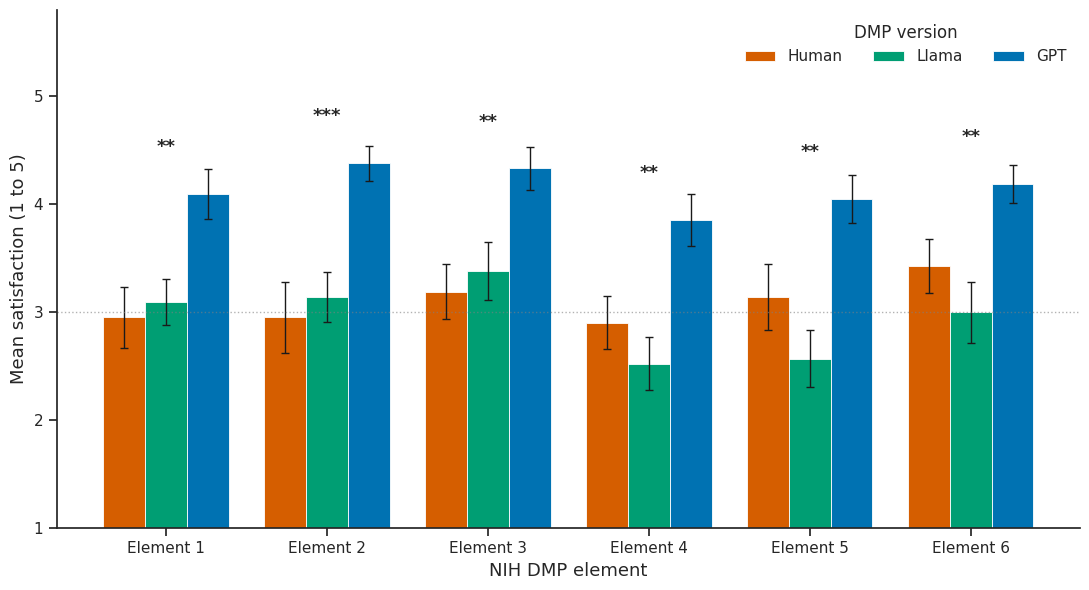

Saved Figure 5: /home/joneill/Nextcloud/vaults/jmind/calmi2/dmp/nih-dmp-llm-evaluation-paper-code/outputs/human-evaluation/figures/figure5_element_satisfaction.png


In [29]:
# Figure 5: per-element mean satisfaction by version, with Friedman significance per element
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks", font="DejaVu Sans", rc={
    "font.size": 10, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 13, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "axes.spines.top": False, "axes.spines.right": False,
})
wong = {"Human": "#D55E00", "Llama": "#009E73", "GPT": "#0072B2"}

_em = _e.groupby(["element_num", "version"])["sat"].agg(["mean", "sem"]).reset_index()
_elements = sorted(_e["element_num"].unique())
_x = np.arange(len(_elements))
_w = 0.26

fig, ax = plt.subplots(figsize=(11, 6))
for i, ver in enumerate(VERSIONS):
    sub = _em[_em["version"] == ver].set_index("element_num").reindex(_elements)
    ax.bar(_x + (i - 1) * _w, sub["mean"], _w, yerr=sub["sem"], label=ver,
           color=wong[ver], edgecolor="white", linewidth=0.6,
           error_kw={"elinewidth": 1.0, "capsize": 3})

_fri = _t6.set_index("scope")
for j, el in enumerate(_elements):
    p = _fri.loc[f"Element {el}", "p"]
    top = _em[_em["element_num"] == el]["mean"].max()
    ax.text(_x[j], top + 0.35, _stars(p), ha="center", va="bottom",
            fontsize=13, fontweight="bold")

ax.set_xticks(_x)
ax.set_xticklabels([f"Element {e}" for e in _elements])
ax.set_ylabel("Mean satisfaction (1 to 5)")
ax.set_xlabel("NIH DMP element")
ax.set_ylim(1, 5.8)
ax.axhline(3, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax.legend(title="DMP version", loc="upper right", frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(_FIG_DIR / "figure5_element_satisfaction.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Saved Figure 5:", _FIG_DIR / "figure5_element_satisfaction.png")